<h1 style="text-decoration: underline;">
Case Study: Biotechnological Process Data Analysis
</h1>

This notebook explores the **“4000 series operating data”** dataset from a large-scale biotechnological process. The dataset contains time-series sensor measurements collected every **5 or 15 minutes** across **22 batches**, capturing the operational state of the process over several hundred hours.

The goal of this analysis is to investigate how **process variables influence product yield**. Using the available operating data and laboratory measurements, we will develop a **data-driven framework** to understand variability in productivity and ultimately predict the yield of an unseen batch.

The key objectives of this notebook are:

1. Explore and understand the structure of the operating and product datasets.
2. Clean and preprocess time-series sensor data (handling missing values, duplicates, and noise).
3. Compute **product rate (kg/hr)** for each batch using laboratory measurements and liquid inflow rates.
4. Rank batches according to productivity.
5. Identify process parameters that correlate with productivity using **machine learning techniques**.
6. Build a predictive model capable of estimating the **product rate of an unseen batch**.

Dataset
Two datasets are used:

- **Operating data** – high-frequency sensor readings (5–15 minute intervals) across **17 process variables**.
- **Product data** – laboratory measurements collected approximately every **4 hours**.

The operating dataset contains approximately **1.4 million observations** across **22 batches**.

The analysis follows a **data engineering → analysis → modelling pipeline**:

1. Data inspection and cleaning
2. Time-series preprocessing
3. Feature extraction at the batch level
4. Statistical and machine learning analysis
5. Predictive modelling

The final outcome will be a **data-driven model identifying the key variables that influence process productivity**.

### **Import modules** & **Load data**

In [1]:
%matplotlib widget

from applied.data_processing import (
    load_operating_data,
    load_product_data,
    compute_product_rate,
)

from applied.plotting import BatchTimeSeriesPlotter
from applied.data_processing import BatchTimeSeriesInspector

from pathlib import Path
import numpy as np

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

### **Data inspection and cleaning (Task1)**

In [3]:
op_df.head()

,Date and time,Batch,LIQUID,LIQUID.1,LIQUID.2,LIQUID.3,LIQUID.4,LIQUID.5,pH,GAS,GAS.1,GAS.2,GAS.3,OFFGAS,OFFGAS.1,PRESSURE,PRESSURE.1,OXYGEN
2,2019-02-04 08:46:00,4030,1049.57,25.91,14.44,NaN,297.73,14980.0,5.76,NaN,NaN,NaN,55.14,1.87,16.94,1.79,5.15,6.78
3,2019-02-04 09:01:00,4030,1049.09,25.62,13.54,NaN,357.44,15000.0,5.79,NaN,NaN,NaN,56.88,1.89,20.52,1.80,5.16,8.39
4,2019-02-04 09:16:00,4030,1049.61,25.44,13.59,NaN,356.83,15010.0,5.80,NaN,NaN,NaN,56.03,1.94,23.77,1.80,5.15,8.07
5,2019-02-04 09:31:00,4030,1047.57,25.59,13.97,NaN,356.77,15000.0,5.79,NaN,NaN,NaN,53.91,2.00,27.01,1.80,5.15,7.23
6,2019-02-04 09:46:00,4030,1048.16,25.49,13.43,NaN,357.21,15010.0,5.78,NaN,NaN,NaN,53.97,2.05,30.15,1.80,5.13,7.16


In [4]:
prod_df.head()

,Date and time,Batch,Product
2,2019-02-04 00:00:00,4030,5.9
3,2019-02-04 02:00:00,4030,8.2
4,2019-02-04 04:00:00,4030,9.7
5,2019-02-04 06:00:00,4030,14.3
6,2019-02-04 08:00:00,4030,16.4


In [5]:
inspector = BatchTimeSeriesInspector(op_df)

summary_df = inspector.summary(only_missing=False)
clean_batches = inspector.batches_by_quality(clean=True)
unclean_batches = inspector.batches_by_quality(clean=False)

In [6]:
inspector.dataset_summary()

,Metric,Value
0,Rows,83204
1,Columns,18
2,Number of batches,22
3,Date start,2019-02-04 08:46:00
4,Date end,2021-05-25 21:35:00
5,Total NaNs,20897


In [7]:
inspector.inspect_batch(clean_batches)

,Batch,start_time,end_time,duration,resolution,rows
2,4033,2019-05-26 17:16:00,2019-06-23 20:01:00,28 days 02:45:00,0 days 00:15:00,2700
3,4034,2019-07-02 13:01:00,2019-08-03 23:46:00,32 days 10:45:00,0 days 00:15:00,3116
4,4035,2019-08-12 17:46:00,2019-09-08 23:46:00,27 days 06:00:00,0 days 00:15:00,2617
5,4036,2019-09-18 12:16:00,2019-10-20 23:46:00,32 days 11:30:00,0 days 00:15:00,3119
6,4037,2019-10-29 04:01:00,2019-11-20 14:31:00,22 days 10:30:00,0 days 00:15:00,2155
7,4038,2019-12-01 01:01:00,2019-12-30 15:31:00,29 days 14:30:00,0 days 00:15:00,2843
12,4043,2020-06-09 19:16:00,2020-06-28 16:16:00,18 days 21:00:00,0 days 00:15:00,1813
13,4044,2020-07-06 23:46:00,2020-07-20 18:16:00,13 days 18:30:00,0 days 00:15:00,1323
14,4045,2020-07-28 20:31:00,2020-08-11 16:16:00,13 days 19:45:00,0 days 00:15:00,1328
15,4046,2020-08-28 01:59:00,2020-10-04 13:14:00,37 days 11:15:00,0 days 00:15:00,3598


In [8]:
inspector.inspect_batch(unclean_batches)

,Batch,start_time,end_time,duration,resolution,rows,missing_timestamps,nan_LIQUID,nan_LIQUID.1,nan_LIQUID.2,...,nan_pH,nan_GAS,nan_GAS.1,nan_GAS.2,nan_GAS.3,nan_OFFGAS,nan_OFFGAS.1,nan_PRESSURE,nan_PRESSURE.1,nan_OXYGEN
0,4030,2019-02-04 08:46:00,2019-03-08 08:16:00,31 days 23:30:00,0 days 00:15:00,3071,0,0,0,0,...,0,708,3071,3071,0,0,0,0,0,0
1,4032,2019-04-01 14:16:00,2019-05-03 06:31:00,31 days 16:15:00,0 days 00:15:00,3042,0,0,0,0,...,0,0,1717,2797,0,0,0,0,0,0
8,4039,2020-01-12 11:16:00,2020-01-30 23:46:00,18 days 12:30:00,0 days 00:15:00,1779,0,15,15,16,...,16,16,16,15,16,16,16,16,15,17
9,4040,2020-02-08 11:31:00,2020-03-08 04:01:00,28 days 16:30:00,0 days 00:15:00,2755,0,1,1,1,...,1,1,1,1,1,1,1,1,1,1
10,4041,2020-03-18 09:31:00,2020-04-15 23:46:00,28 days 14:15:00,0 days 00:15:00,2742,4,0,0,0,...,1,0,0,0,0,2,2,0,1,0
11,4042,2020-04-24 00:16:00,2020-05-29 23:46:00,35 days 23:30:00,0 days 00:15:00,3002,453,4,4,3,...,4,3,4,4,4,4,4,4,3,3
16,4047,2020-10-13 23:29:00,2020-11-13 20:29:00,30 days 21:00:00,0 days 00:15:00,2969,-4,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19,4051,2021-01-28 22:50:00,2021-03-01 21:50:00,31 days 23:00:00,0 days 00:05:00,9204,1,407,398,403,...,406,406,403,403,403,402,400,399,403,403
20,4052,2021-03-10 21:05:00,2021-04-13 01:50:00,33 days 04:45:00,0 days 00:05:00,9550,12,0,0,0,...,0,1,0,0,0,7,5,0,0,0
21,4053,2021-04-27 16:35:00,2021-05-25 21:35:00,28 days 05:00:00,0 days 00:05:00,8125,0,0,0,0,...,0,1,0,0,1,7,2,0,0,0


In [9]:
inspector.inspect_batch(4041)

,Batch,start_time,end_time,duration,resolution,rows,missing_timestamps,nan_pH,nan_OFFGAS,nan_OFFGAS.1,nan_PRESSURE.1
10,4041,2020-03-18 09:31:00,2020-04-15 23:46:00,28 days 14:15:00,0 days 00:15:00,2742,4,1,2,2,1


LETS VISULAE MISSING DATA HEY 

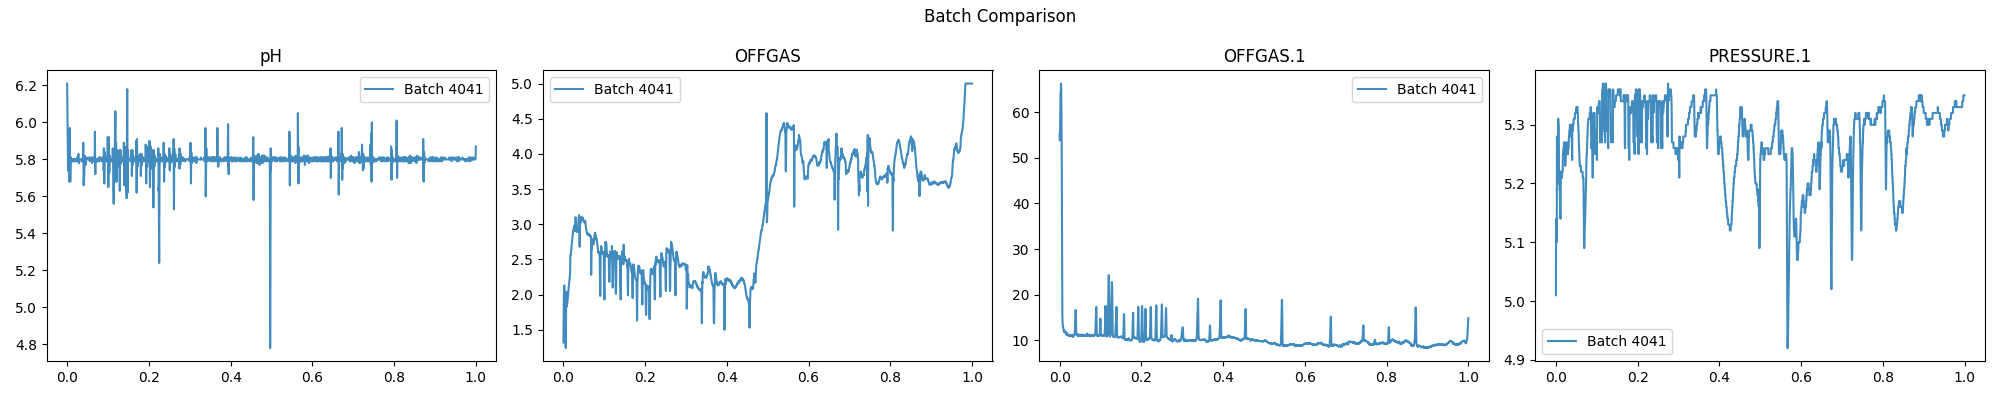

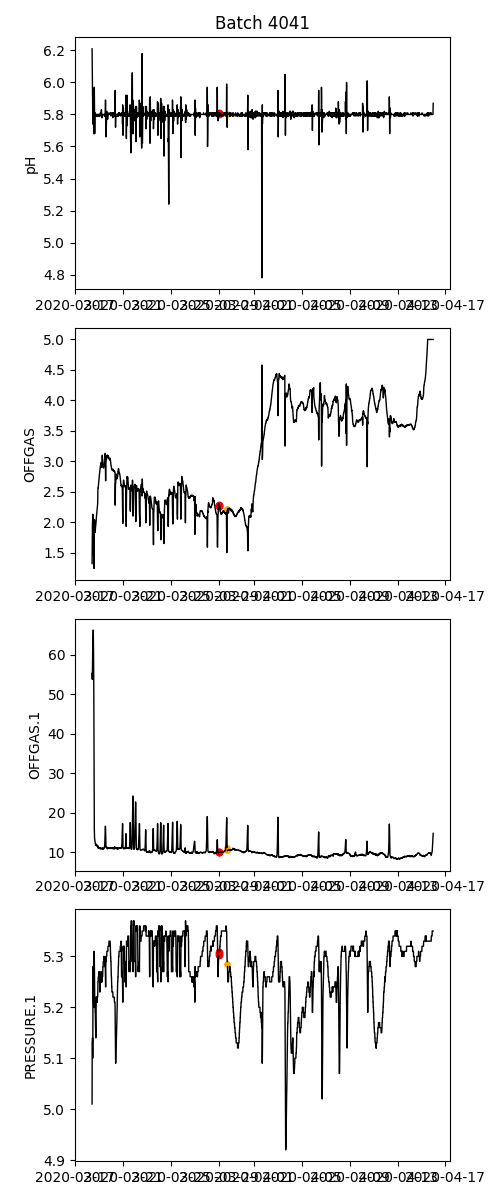

In [10]:
plotter = BatchTimeSeriesPlotter(op_df)


plotter.plot(batch=4041, column=["pH","OFFGAS","OFFGAS.1", 'PRESSURE.1'], width=6)

plotter.plot_batches_grid(columns=["pH","OFFGAS","OFFGAS.1", 'PRESSURE.1'], batches=4041)


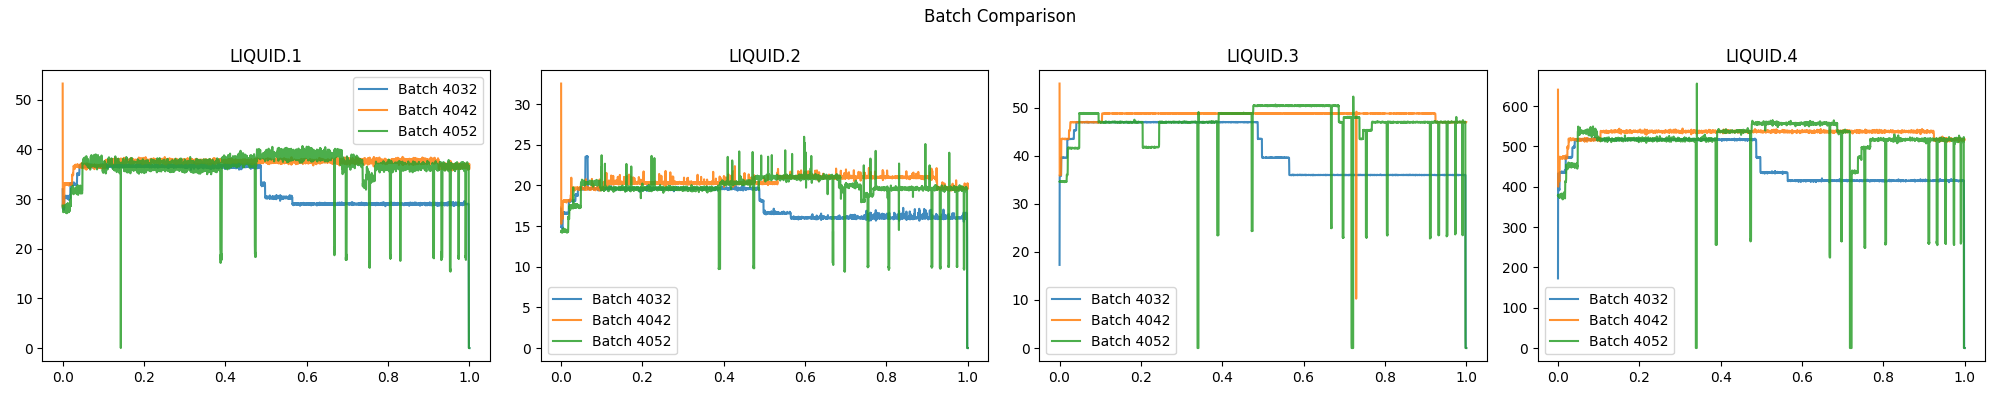

In [11]:
# UPDATE SO ITS THE RIGHT PLOTTER 

plotter = BatchTimeSeriesPlotter(op_df)

plotter.plot(batch=[4032, 4042, 4052], column=["LIQUID.1","LIQUID.2","LIQUID.3", 'LIQUID.4'], width=6)
# plotter.plot(batch=[4032, 4052], column=["GAS",'GAS.1', 'GAS.2', 'GAS.3'])
# plotter.plot(batch=[4032, 4052], column=["PRESSURE",'PRESSURE.1'])

/Users/richardfisher/Desktop/Applied/src/applied/plotting.py:380: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


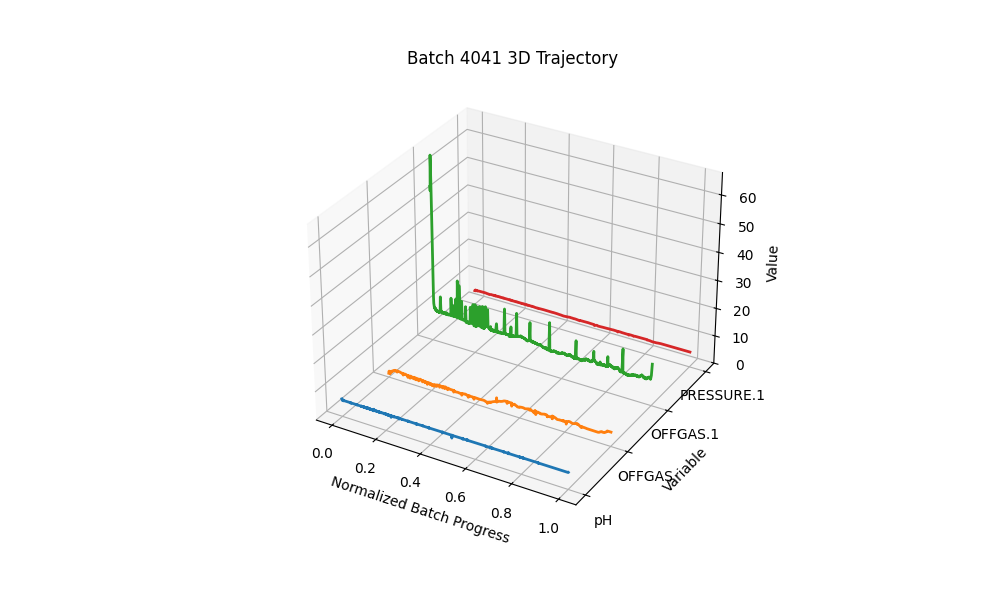

In [12]:
plotter.plot_batch_3d(
    batch=4041,
    columns=["pH","OFFGAS","OFFGAS.1","PRESSURE.1"]
)

NOW NEED TO DO PRODUCTION DATA 

In [13]:
inspector = BatchTimeSeriesInspector(prod_df)

summary_df = inspector.summary(only_missing=False)
clean_batches = inspector.batches_by_quality(clean=True)
unclean_batches = inspector.batches_by_quality(clean=False)

### **Ranking productivity of batch Product Rate(Task2&3)**

Compute the **product rate** for each batch using the following formula:

$$
\text{Product Rate (kg/hr)} =
\text{mean product (g/L)} \times
\text{mean total liquid inflow rate (L/hr)} \times 0.001
$$

where the **total liquid inflow rate** is defined as:

$$
\text{Total liquid inflow} =
\sum_{i=1}^{6} \text{liquid inflow}_i
$$

Using the computed product rates, **rank the productivity of the batches**.  
The product rate is a valid comparison metric across batches and is **independent of batch duration**, which is highly variable.

In [14]:
##### ADD THE CLEAN, UNCLEAN TAG


import pandas as pd

def compute_batch_productivity(op_df, prod_df):

    liquid_cols = [
        "LIQUID", "LIQUID.1", "LIQUID.2",
        "LIQUID.3", "LIQUID.4", "LIQUID.5"
    ]

    op_df = op_df.copy()
    prod_df = prod_df.copy()

    # total liquid inflow per row
    op_df["total_liquid_inflow"] = op_df[liquid_cols].sum(axis=1, skipna=True)

    # batch means
    mean_liquid = (
        op_df.groupby("Batch")["total_liquid_inflow"]
        .mean()
        .rename("mean_total_liquid")
    )

    mean_product = (
        prod_df.groupby("Batch")["Product"]
        .mean()
        .rename("mean_product")
    )

    # combine
    batch_product_rate = pd.concat(
        [mean_product, mean_liquid],
        axis=1
    )

    # product rate
    batch_product_rate["product_rate_kg_hr"] = (
        batch_product_rate["mean_product"]
        * batch_product_rate["mean_total_liquid"]
        * 0.001
    )

    # rank batches by productivity
    batch_product_rate = (
        batch_product_rate
        .sort_values("product_rate_kg_hr", ascending=False)
        .assign(productivity_rank=lambda df: range(1, len(df) + 1))
    )

    return batch_product_rate

batch_product_rate = compute_batch_productivity(op_df, prod_df)
batch_product_rate

,mean_product,mean_total_liquid,product_rate_kg_hr,productivity_rank
Batch,,,,
4041,27.263270,24583.602688,670.229408,1
4043,27.041068,24753.736520,669.367477,2
4047,26.370833,25144.553486,663.082829,3
4040,26.450455,24623.509532,651.303020,4
4042,26.367835,24493.636569,645.844169,5
4046,26.017734,24782.597009,644.787017,6
4045,26.591552,24100.309285,640.864621,7
4052,25.787324,24405.554019,629.353928,8
4034,25.052205,24835.980215,622.196071,9


### **Feature Engineering**

A Highly data driven approch was adpoeted due to ... 

We expement lightly with generated features.

Visually 

MAY JUST DITCH THIS SECTION TBH 

### **Identifying Process Drivers of Product Rate (Task4)**

Use **machine learning procedures** to identify the **process parameters most clearly related to product rate variability**.

In [25]:
from applied.data_processing import build_features_and_target
from applied.models import correlation_report

X, y = build_features_and_target(op_df, prod_df)

In [28]:
feature_corr = correlation_report(X, threshold=0.8, mode="feature")
target_corr = correlation_report(X, y, threshold=0.7, mode="target")
features = target_corr["Feature"].tolist()

print(feature_corr, '\n\n', target_corr)

       Feature_1      Feature_2  Correlation
0  LIQUID.1_mean  LIQUID.4_mean     0.979476
1    LIQUID_mean     GAS.3_mean     0.893235 

        Feature  Correlation_with_Target
0  LIQUID_mean                 0.948973
1   GAS.3_mean                 0.867120


Ridge: mean RMSE = 15.9614
Lasso: mean RMSE = 11.3362
ElasticNet: mean RMSE = 15.4131
RandomForest: mean RMSE = 22.6733
HistGradientBoosting: mean RMSE = 36.1285


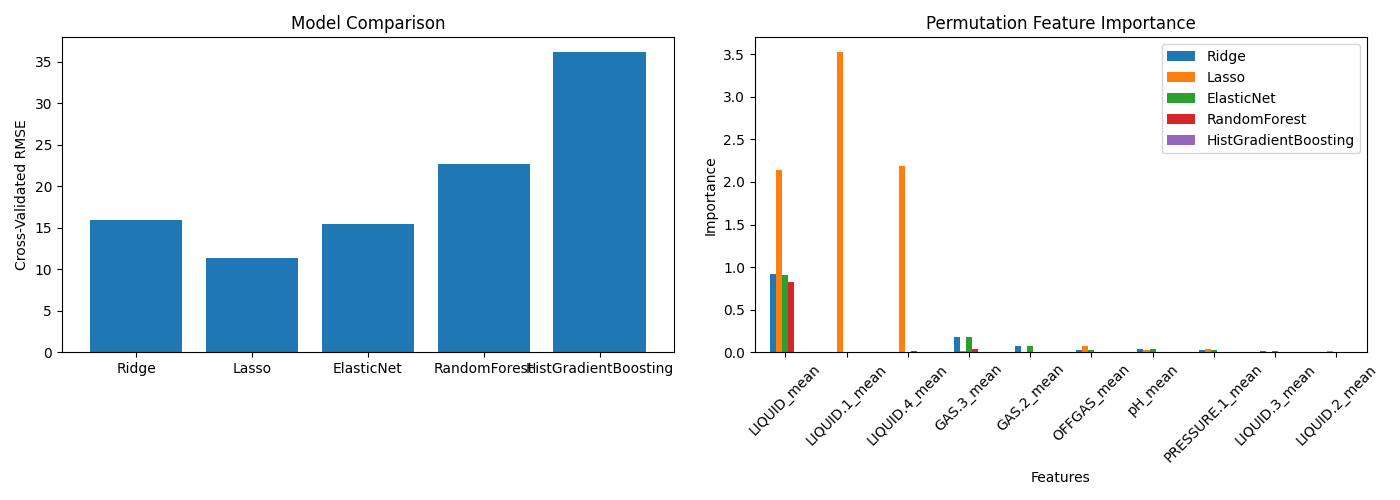

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance


class ModelEvaluator:

    def __init__(self, n_splits=5, random_state=42):

        self.random_state = random_state

        self.cv = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        self.models = {

            "Ridge": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Ridge(alpha=1.0)),
            ]),

            "Lasso": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Lasso(alpha=0.01, max_iter=10000)),
            ]),

            "ElasticNet": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000)),
            ]),

            "RandomForest": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestRegressor(
                    n_estimators=800,
                    min_samples_leaf=5,
                    random_state=random_state,
                    n_jobs=-1
                )),
            ]),

            "HistGradientBoosting": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", HistGradientBoostingRegressor(
                    max_iter=500,
                    learning_rate=0.05,
                    random_state=random_state
                )),
            ]),
        }

        self.results = None
        self.importance_df = None


    def evaluate(self, X, y):

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        results = {}

        for name, model in self.models.items():

            rmse = -cross_val_score(
                model,
                X,
                y,
                scoring="neg_root_mean_squared_error",
                cv=self.cv
            ).mean()

            results[name] = rmse
            print(f"{name}: mean RMSE = {rmse:.4f}")

        self.results = results
        return results


    def plot_model_rmse(self, ax=None):

        if self.results is None:
            raise ValueError("Run evaluate() first.")

        if ax is None:
            fig, ax = plt.subplots()

        ax.bar(self.results.keys(), self.results.values())

        ax.set_ylabel("Cross-Validated RMSE")
        ax.set_title("Model Comparison")


    def compute_permutation_importance(self, X, y, n_repeats=20):

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        importance_dict = {}

        for name, model in self.models.items():

            model.fit(X, y)

            perm = permutation_importance(
                model,
                X,
                y,
                n_repeats=n_repeats,
                random_state=self.random_state,
                n_jobs=-1
            )

            importance = pd.Series(
                perm.importances_mean,
                index=X.columns
            )

            importance_dict[name] = importance

        self.importance_df = pd.DataFrame(importance_dict)

        return self.importance_df


    def plot_permutation_importance(self, top_n=10, ax=None):

        if self.importance_df is None:
            raise ValueError("Run compute_permutation_importance() first.")

        if ax is None:
            fig, ax = plt.subplots()

        importance_df = self.importance_df.copy()

        top_features = (
            importance_df.mean(axis=1)
            .sort_values(ascending=False)
            .head(top_n)
            .index
        )

        data = importance_df.loc[top_features]

        data.plot(kind="bar", ax=ax)

        ax.set_title("Permutation Feature Importance")
        ax.set_ylabel("Importance")
        ax.set_xlabel("Features")
        ax.tick_params(axis='x', rotation=45)


# -------------------------
# Run evaluation + plots
# -------------------------

evaluator = ModelEvaluator()

evaluator.evaluate(X, y)
evaluator.compute_permutation_importance(X, y)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

evaluator.plot_model_rmse(ax=axes[0])
evaluator.plot_permutation_importance(top_n=10, ax=axes[1])

plt.tight_layout()
plt.show()

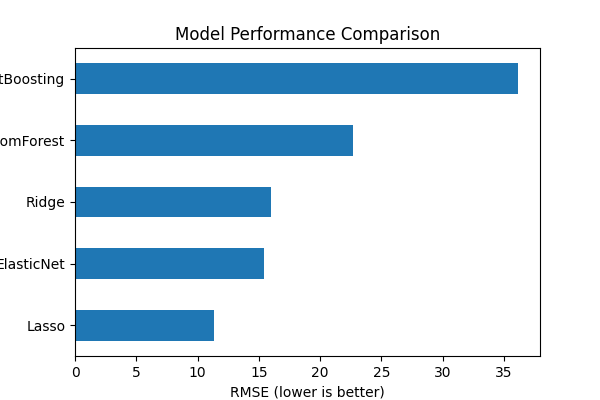

In [50]:
rmse = {
    "Ridge": 15.9614,
    "Lasso": 11.3362,
    "ElasticNet": 15.4131,
    "RandomForest": 22.6733,
    "HistGradientBoosting": 36.1285
}

import pandas as pd
import matplotlib.pyplot as plt

s = pd.Series(rmse).sort_values()

plt.figure(figsize=(6,4))
s.plot(kind="barh")

plt.xlabel("RMSE (lower is better)")
plt.title("Model Performance Comparison")

plt.show()

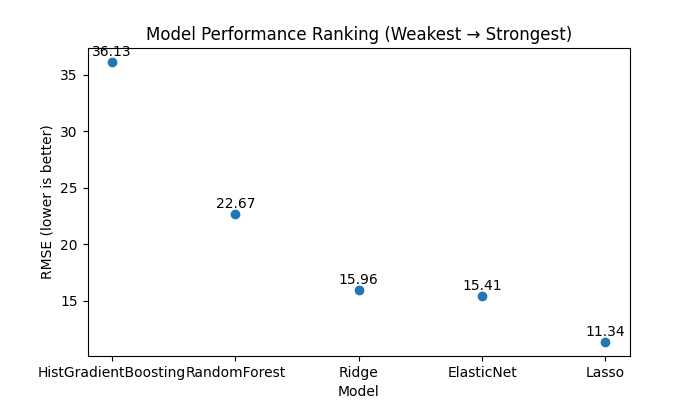

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

rmse = {
    "Ridge": 15.9614,
    "Lasso": 11.3362,
    "ElasticNet": 15.4131,
    "RandomForest": 22.6733,
    "HistGradientBoosting": 36.1285
}

# Convert to Series
rmse_series = pd.Series(rmse)

# Order weakest -> strongest
rmse_series = rmse_series.sort_values(ascending=False)

plt.figure(figsize=(7,4))

plt.scatter(rmse_series.index, rmse_series.values)

for i, v in enumerate(rmse_series.values):
    plt.text(i, v + 0.5, f"{v:.2f}", ha="center")

plt.ylabel("RMSE (lower is better)")
plt.xlabel("Model")
plt.title("Model Performance Ranking (Weakest → Strongest)")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance


class ModelEvaluator:

    def __init__(self, n_splits=5, random_state=42):

        self.random_state = random_state

        self.cv = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        self.models = {

            "Ridge": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Ridge(alpha=1.0)),
            ]),

            "Lasso": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Lasso(alpha=0.01, max_iter=10000)),
            ]),

            "ElasticNet": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000)),
            ]),

            "RandomForest": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestRegressor(
                    n_estimators=800,
                    min_samples_leaf=5,
                    random_state=random_state,
                    n_jobs=-1
                )),
            ]),

            "HistGradientBoosting": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", HistGradientBoostingRegressor(
                    max_iter=500,
                    learning_rate=0.05,
                    random_state=random_state
                )),
            ]),
        }

        self.results = None
        self.importance_df = None


    def evaluate(self, X, y):

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        results = {}

        for name, model in self.models.items():

            rmse = -cross_val_score(
                model,
                X,
                y,
                scoring="neg_root_mean_squared_error",
                cv=self.cv
            ).mean()

            results[name] = rmse
            print(f"{name}: mean RMSE = {rmse:.4f}")

        self.results = results
        return results


    def plot_model_rmse(self):

        if self.results is None:
            raise ValueError("Run evaluate() first.")

        plt.figure(figsize=(7,4))

        plt.bar(self.results.keys(), self.results.values())

        plt.ylabel("Cross-Validated RMSE")
        plt.title("Model Comparison")

        plt.show()


    def compute_permutation_importance(self, X, y, n_repeats=20):

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        importance_dict = {}

        for name, model in self.models.items():

            model.fit(X, y)

            perm = permutation_importance(
                model,
                X,
                y,
                n_repeats=n_repeats,
                random_state=self.random_state,
                n_jobs=-1
            )

            importance = pd.Series(
                perm.importances_mean,
                index=X.columns
            )

            importance_dict[name] = importance

        self.importance_df = pd.DataFrame(importance_dict)

        return self.importance_df


    def plot_permutation_importance(self, top_n=10):

        if self.importance_df is None:
            raise ValueError("Run compute_permutation_importance() first.")

        importance_df = self.importance_df.copy()

        top_features = (
            importance_df.mean(axis=1)
            .sort_values(ascending=False)
            .head(top_n)
            .index
        )

        data = importance_df.loc[top_features]

        data.plot(kind="bar", figsize=(10,6))

        plt.title("Permutation Feature Importance Comparison")
        plt.ylabel("Importance")
        plt.xlabel("Features")

        plt.xticks(rotation=45)

        plt.legend(title="Model")

        plt.tight_layout()
        plt.show()

Ridge: mean RMSE = 15.9614
Lasso: mean RMSE = 11.3362
ElasticNet: mean RMSE = 15.4131
RandomForest: mean RMSE = 22.6733
HistGradientBoosting: mean RMSE = 36.1285


/var/folders/46/ddlt6_p52754jxg3fjz3_g2w0000gn/T/ipykernel_62631/3502059830.py:100: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(7,4))


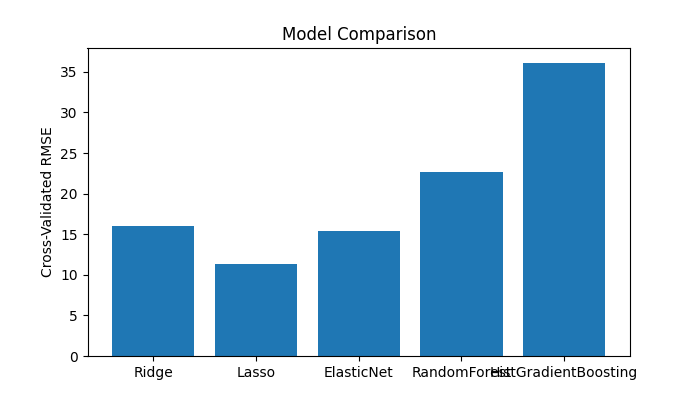

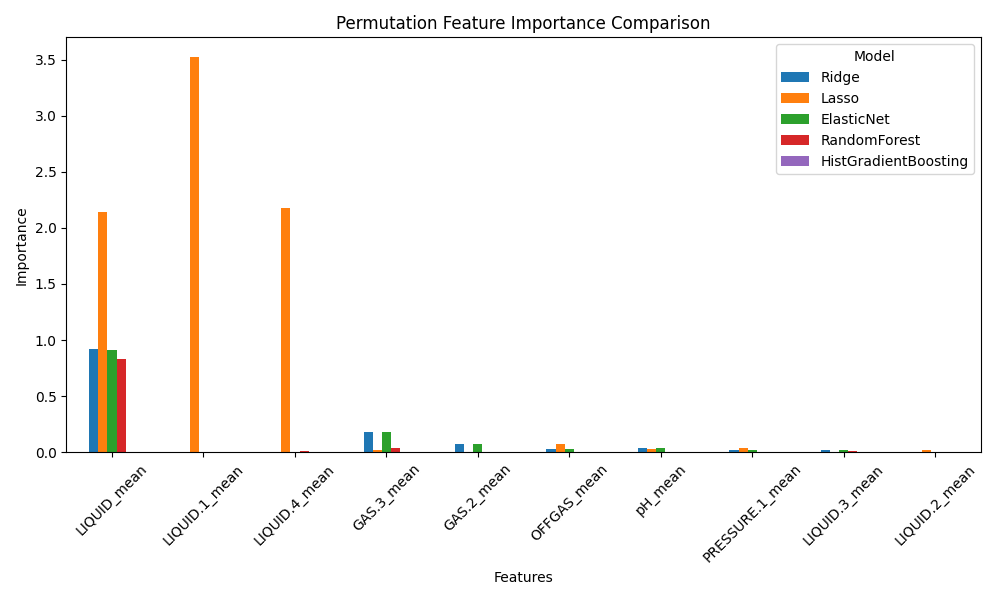

In [ ]:
evaluator = ModelEvaluator()

# model comparison
evaluator.evaluate(X, y)

# permutation importance
evaluator.compute_permutation_importance(X, y)

# combined plot
evaluator.plot_permutation_importance(top_n=10)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.inspection import permutation_importance


class ModelEvaluator:

    def __init__(self, n_splits=5, random_state=42):

        self.random_state = random_state

        self.cv = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        self.models = {

            "Ridge": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Ridge(alpha=1.0)),
            ]),

            "Lasso": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Lasso(
                    alpha=0.01,
                    max_iter=10000
                )),
            ]),

            "ElasticNet": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", ElasticNet(
                    alpha=0.1,
                    l1_ratio=0.5,
                    max_iter=20000
                )),
            ]),

            "RandomForest": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestRegressor(
                    n_estimators=800,
                    min_samples_leaf=5,
                    random_state=random_state,
                    n_jobs=-1
                )),
            ]),

            "HistGradientBoosting": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", HistGradientBoostingRegressor(
                    max_iter=500,
                    learning_rate=0.05,
                    random_state=random_state
                )),
            ]),

        }

        self.results = None


    def evaluate(self, X, y):

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        results = {}

        for name, model in self.models.items():

            rmse = -cross_val_score(
                model,
                X,
                y,
                scoring="neg_root_mean_squared_error",
                cv=self.cv
            ).mean()

            results[name] = rmse
            print(f"{name}: mean RMSE = {rmse:.4f}")

        self.results = results
        return results


    def plot_model_rmse(self):

        if self.results is None:
            raise ValueError("Run evaluate() first.")

        plt.figure(figsize=(6,4))
        plt.bar(self.results.keys(), self.results.values())

        plt.ylabel("Cross-Validated RMSE")
        plt.title("Model Comparison")

        plt.show()


    def permutation_importance(self, model_name, X, y, n_repeats=20):

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        model = self.models[model_name]
        model.fit(X, y)

        perm = permutation_importance(
            model,
            X,
            y,
            n_repeats=n_repeats,
            random_state=42,
            n_jobs=-1
        )

        importance = pd.Series(
            perm.importances_mean,
            index=X.columns
        ).sort_values(ascending=False)

        return importance


    def plot_permutation_importance2(self, importance, top_n=10):

        top_features = importance.head(top_n)

        plt.figure(figsize=(8,6))

        top_features.sort_values().plot(kind="barh")

        plt.xlabel("Permutation Importance")
        plt.title(f"Top {top_n} Process Parameters Influencing Product Rate")

        plt.show()

    def plot_permutation_importance(self, importance_dict, top_n=10):

        """
        importance_dict: dict
            {"ModelName": importance_series}
        """

        # combine importance from models
        df = pd.concat(importance_dict, axis=1)

        # average importance to select top features
        top_features = df.mean(axis=1).sort_values(ascending=False).head(top_n).index

        df = df.loc[top_features]

        plt.figure(figsize=(10,6))

        df.sort_values(by=df.columns.tolist()).plot(
            kind="barh",
            figsize=(10,6)
        )

        plt.xlabel("Permutation Importance")
        plt.title("Feature Importance Comparison Across Models")

        plt.legend(title="Model")

        plt.show()


    import pandas as pd
import matplotlib.pyplot as plt

# Compute permutation importances
importance_rf = evaluator.permutation_importance("RandomForest", X, y)
importance_ridge = evaluator.permutation_importance("Ridge", X, y)
importance_lasso = evaluator.permutation_importance("Lasso", X, y)
importance_elastic = evaluator.permutation_importance("ElasticNet", X, y)
importance_hgb = evaluator.permutation_importance("HistGradientBoosting", X, y)

# Combine into one DataFrame
importance_df = pd.concat(
    [importance_rf, importance_ridge, importance_lasso, importance_elastic, importance_hgb],
    axis=1
)

importance_df.columns = [
    "RandomForest",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "HistGradientBoosting"
]

# Plot function
def plot_permutation_importance(importance_df, top_n=10):

    top_features = importance_df.mean(axis=1).sort_values(ascending=False).head(top_n).index
    data = importance_df.loc[top_features]

    data.plot(kind="bar", figsize=(10,6))

    plt.title("Permutation Feature Importance Comparison")
    plt.ylabel("Importance")
    plt.xlabel("Features")
    plt.xticks(rotation=45)
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

# Run plot
plot_permutation_importance(importance_df, top_n=10)

In [35]:
evaluator = ModelEvaluator()


importance_rf = evaluator.permutation_importance("RandomForest", X, y)
importance_ridge = evaluator.permutation_importance("Ridge", X, y)
importance_lasso = evaluator.permutation_importance("Lasso", X, y)

importance_dict = {
    "RandomForest": importance_rf,
    "Ridge": importance_ridge,
    "Lasso": importance_lasso
}

evaluator.plot_permutation_importance(importance_dict, top_n=10)

AttributeError: 'dict' object has no attribute 'head'

Ridge: mean RMSE = 15.9614
Lasso: mean RMSE = 11.3362
ElasticNet: mean RMSE = 15.4131
RandomForest: mean RMSE = 22.6733
HistGradientBoosting: mean RMSE = 36.1285


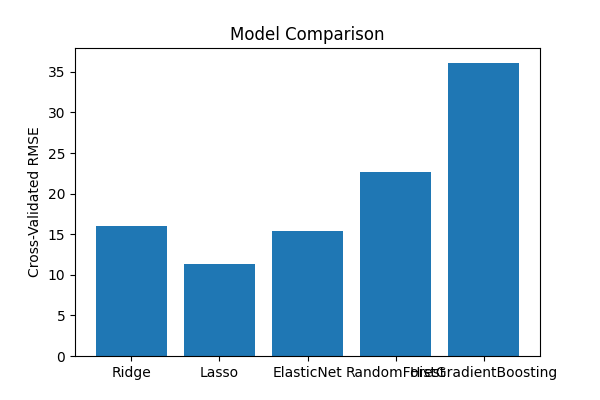

In [45]:
evaluator = ModelEvaluator()

results = evaluator.evaluate(X, y)

evaluator.plot_model_rmse()

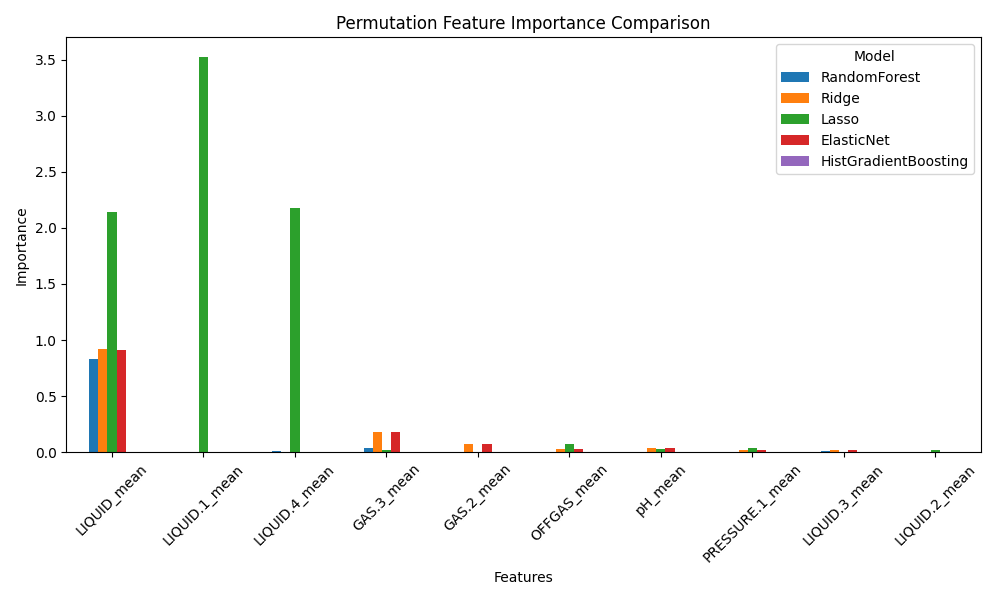

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute permutation importances
importance_rf = evaluator.permutation_importance("RandomForest", X, y)
importance_ridge = evaluator.permutation_importance("Ridge", X, y)
importance_lasso = evaluator.permutation_importance("Lasso", X, y)
importance_elastic = evaluator.permutation_importance("ElasticNet", X, y)
importance_hgb = evaluator.permutation_importance("HistGradientBoosting", X, y)

# Combine into one DataFrame
importance_df = pd.concat(
    [importance_rf, importance_ridge, importance_lasso, importance_elastic, importance_hgb],
    axis=1
)

importance_df.columns = [
    "RandomForest",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "HistGradientBoosting"
]

# Plot function
def plot_permutation_importance(importance_df, top_n=10):

    top_features = importance_df.mean(axis=1).sort_values(ascending=False).head(top_n).index
    data = importance_df.loc[top_features]

    data.plot(kind="bar", figsize=(10,6))

    plt.title("Permutation Feature Importance Comparison")
    plt.ylabel("Importance")
    plt.xlabel("Features")
    plt.xticks(rotation=45)
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

# Run plot
plot_permutation_importance(importance_df, top_n=10)

In [ ]:
# import numpy as np
# import pandas as pd

# def add_product_to_operating(df_op, df_p, tolerance_minutes=10):

#     df_op = df_op.copy()
#     df_op["Product"] = np.nan

#     for batch, p_batch in df_p.groupby("Batch"):

#         op_indices = df_op.index[df_op["Batch"] == batch]
#         op_times = df_op.loc[op_indices, "Date and time"].to_numpy()

#         for _, row in p_batch.iterrows():

#             product_time = np.datetime64(row["Date and time"])
#             product_value = row["Product"]

#             diffs = np.abs((op_times - product_time) / np.timedelta64(1, "m"))
#             nearest_idx = np.argmin(diffs)

#             if diffs[nearest_idx] <= tolerance_minutes:

#                 df_op.loc[op_indices[nearest_idx], "Product"] = product_value

#     return df_op

# def add_total_liquid_inflow(X):

#     liquid_cols = [
#         "LIQUID", "LIQUID.1", "LIQUID.2",
#         "LIQUID.3", "LIQUID.4", "LIQUID.5"
#     ]

#     X = X.copy()

#     X["total_liquid_inflow"] = X[liquid_cols].sum(axis=1, skipna=True)

#     return X

# def move_product_to_end(df, product_col="Product"):

#     cols = [c for c in df.columns if c != product_col]
#     cols.append(product_col)

#     return df[cols]

# X = add_total_liquid_inflow(X)

# X = move_product_to_end(X)

# df_product_rate_per_batch = compute_batch_product_rate(X)

# df_product_rate_per_batch

### **Constructing a Predictive Model (Task5)**

Construct a **mathematical and/or computational model** that incorporates the insights from **Task 4** into a **predictive framework**.

Predictive Model Construction

Based on the feature importance analysis in Task 4, a reduced predictive framework was constructed using the most influential process parameters.

A Random Forest regressor was selected due to its superior cross-validated performance and ability to model non-linear interactions between process variables.

Predictive form:

y_hat = f(P, G_in, G_off, O2, L_in, pH)

where f(.) is a non-linear ensemble mapping learned via bootstrap aggregation of decision trees.

Cross-validation was used to estimate generalisation performance.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Reduced feature set from Task 4
X_reduced = X_clean[features].copy()
y_target = y_clean.copy()

# Predictive framework
framework = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ))
])

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = -cross_val_score(
    framework,
    X_reduced,
    y_target,
    scoring="neg_root_mean_squared_error",
    cv=cv
)

print(f"Cross-validated RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")

Cross-validated RMSE: 14.197 ± 5.504


Train/test split + performance metrics

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import numpy as np

X_reduced = X_clean[features].copy()
y_target = y_clean.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_target, test_size=0.2, random_state=42
)

framework = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)),
])

framework.fit(X_train, y_train)
y_pred = framework.predict(X_test)

# RMSE compatible with older sklearn:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE:  {mae:.3f}")
print(f"Test R²:   {r2:.3f}")

Test RMSE: 7.735
Test MAE:  6.864
Test R²:   0.872


Predicted Vs Actual

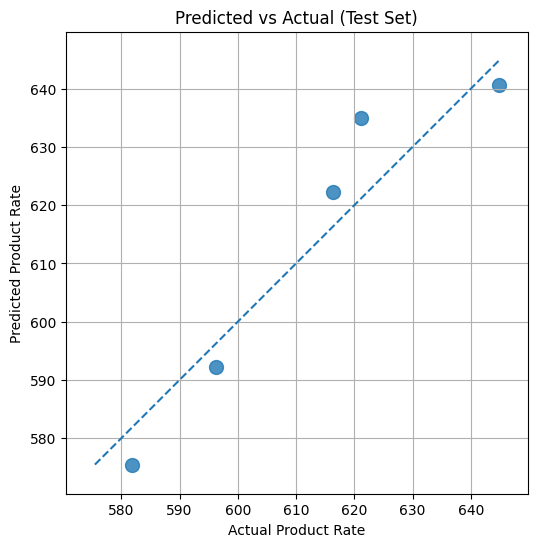

In [27]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, s=100, alpha=0.8)

# Perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Product Rate")
plt.ylabel("Predicted Product Rate")
plt.title("Predicted vs Actual (Test Set)")
plt.grid(True)

plt.xlim(min_val - 5, max_val + 5)
plt.ylim(min_val - 5, max_val + 5)

plt.gca().set_aspect('equal', adjustable='box')

plt.show()

The predicted versus actual plot demonstrates reasonable alignment with the 1:1 reference line, indicating that the Random Forest model captures a substantial proportion of productivity variability across batches. Most predictions lie close to the ideal line, although the highest productivity batch is moderately underpredicted, suggesting mild regression toward the mean. This behaviour is typical of ensemble tree models trained on relatively small datasets. Overall, the model exhibits stable generalisation performance without evidence of systematic bias.

Residuals Vs Pred

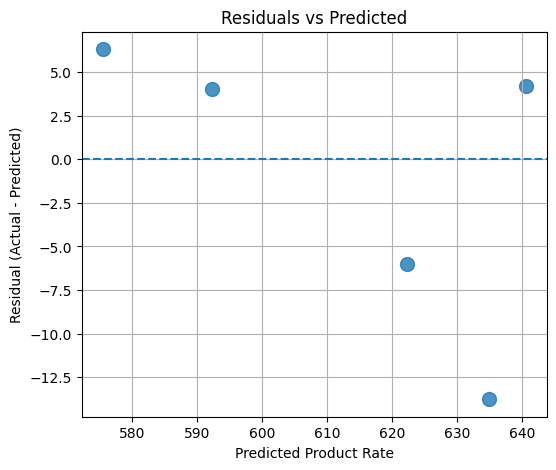

In [28]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, s=100, alpha=0.8)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Product Rate")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.grid(True)

plt.show()

Residuals are distributed around zero without clear structural pattern, indicating that the model does not exhibit strong systematic bias across the prediction range.

In [30]:
import pandas as pd

pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Value": [rmse, mae, r2]
})

,Metric,Value
0,RMSE,7.735395
1,MAE,6.863963
2,R²,0.872102


### **Predicting the Missing Yield Rate (Task6)**

Use the developed model to **predict the “missing” yield rate**.